In [4]:
pip install pandas

Note: you may need to restart the kernel to use updated packages.


In [5]:
pip install pandas numpy matplotlib seaborn

Note: you may need to restart the kernel to use updated packages.


In [14]:
import pandas as pd

In [15]:
customers = pd.read_csv("olist_customers_dataset.csv")
print(customers.shape)

(99441, 5)


In [16]:
orders = pd.read_csv("olist_orders_dataset.csv")
items = pd.read_csv("olist_order_items_dataset.csv")
payments = pd.read_csv("olist_order_payments_dataset.csv")

In [17]:
print(customers.shape, orders.shape, items.shape, payments.shape)

(99441, 5) (99441, 8) (112650, 7) (103886, 5)


In [18]:
print(orders["order_status"].value_counts())

order_status
delivered      96478
shipped         1107
canceled         625
unavailable      609
invoiced         314
processing       301
created            5
approved           2
Name: count, dtype: int64


In [19]:
print("Unique customers:", customers["customer_unique_id"].nunique())

Unique customers: 96096


In [20]:
df = orders.merge(customers, on="customer_id", how="left")
print(df.shape)

(99441, 12)


In [21]:
df = df[df["order_status"] == "delivered"].copy()
print(df.shape)

(96478, 12)


In [22]:
df["order_purchase_timestamp"] = pd.to_datetime(df["order_purchase_timestamp"])
df["order_month"] = df["order_purchase_timestamp"].dt.to_period("M")

In [23]:
print(df[["customer_unique_id", "order_purchase_timestamp"]].isnull().sum())

customer_unique_id          0
order_purchase_timestamp    0
dtype: int64


In [24]:
print("Duplicate order_ids:", df["order_id"].duplicated().sum())

Duplicate order_ids: 0


In [25]:
print("Total orders:", df["order_id"].nunique())
print("Unique customers:", df["customer_unique_id"].nunique())
print("Date range:", df["order_purchase_timestamp"].min(), "to", df["order_purchase_timestamp"].max())

Total orders: 96478
Unique customers: 93358
Date range: 2016-09-15 12:16:38 to 2018-08-29 15:00:37


In [26]:
df = df[df["order_status"] == "delivered"].copy()
print(df.shape)

(96478, 13)


In [4]:
%pwd

'C:\\Users\\MY PC\\Downloads'

In [5]:
import pandas as pd

path = "archive (3)"

customers = pd.read_csv(path + "/olist_customers_dataset.csv")
orders = pd.read_csv(path + "/olist_orders_dataset.csv")
items = pd.read_csv(path + "/olist_order_items_dataset.csv")
payments = pd.read_csv(path + "/olist_order_payments_dataset.csv")

df = orders.merge(customers, on="customer_id", how="left")
df = df[df["order_status"] == "delivered"].copy()

df["order_purchase_timestamp"] = pd.to_datetime(df["order_purchase_timestamp"])
df["order_month"] = df["order_purchase_timestamp"].dt.to_period("M")

print(df.shape)

(96478, 13)


In [6]:
print(df[["customer_unique_id", "order_purchase_timestamp"]].isnull().sum())

customer_unique_id          0
order_purchase_timestamp    0
dtype: int64


In [7]:
print("Duplicate order_ids:", df["order_id"].duplicated().sum())

Duplicate order_ids: 0


In [8]:
print("Total orders:", df["order_id"].nunique())
print("Unique customers:", df["customer_unique_id"].nunique())
print("Date range:", df["order_purchase_timestamp"].min(), "to", df["order_purchase_timestamp"].max())

Total orders: 96478
Unique customers: 93358
Date range: 2016-09-15 12:16:38 to 2018-08-29 15:00:37


In [9]:
orders_per_customer = df.groupby("customer_unique_id")["order_id"].nunique()
print(orders_per_customer.value_counts().head())

order_id
1    90557
2     2573
3      181
4       28
5        9
Name: count, dtype: int64


In [10]:
total_customers = orders_per_customer.shape[0]
repeat_customers = (orders_per_customer > 1).sum()
repeat_rate = repeat_customers / total_customers * 100

print("Total customers:", total_customers)
print("Repeat customers:", repeat_customers)
print("Repeat rate:", round(repeat_rate, 2), "%")

Total customers: 93358
Repeat customers: 2801
Repeat rate: 3.0 %


In [11]:
df = df.drop(columns="payment_value", errors="ignore")

order_value = payments.groupby("order_id")["payment_value"].sum().reset_index()
df = df.merge(order_value, on="order_id", how="left")

print(df["payment_value"].isnull().sum())

1


In [12]:
aov = df["payment_value"].mean()
print("Average Order Value:", round(aov, 2))

Average Order Value: 159.86


In [15]:
import numpy as np

In [16]:
customer_orders = df.groupby("customer_unique_id").agg(
    orders=("order_id", "nunique"),
    total_spend=("payment_value", "sum")
).reset_index()

customer_orders["type"] = np.where(customer_orders["orders"] > 1, "Repeat", "One-time")

print(customer_orders.groupby("type")["total_spend"].agg(["count", "mean", "sum"]))

          count        mean          sum
type                                    
One-time  90557  160.761781  14558104.56
Repeat     2801  308.588793    864357.21


In [17]:
df["cohort_month"] = df.groupby("customer_unique_id")["order_month"].transform("min")

In [18]:
df["cohort_index"] = (
    (df["order_month"].dt.year - df["cohort_month"].dt.year) * 12
    + (df["order_month"].dt.month - df["cohort_month"].dt.month)
)

In [19]:
cohort_data = df.groupby(["cohort_month", "cohort_index"])["customer_unique_id"].nunique().reset_index()

cohort_counts = cohort_data.pivot(index="cohort_month", columns="cohort_index", values="customer_unique_id")
print(cohort_counts.head())

cohort_index      0    1    2    3    4    5    6    7    8    9    10   11  \
cohort_month                                                                  
2016-09          1.0  NaN  NaN  NaN  NaN  NaN  NaN  NaN  NaN  NaN  NaN  NaN   
2016-10        262.0  NaN  NaN  NaN  NaN  NaN  1.0  NaN  NaN  1.0  NaN  1.0   
2016-12          1.0  1.0  NaN  NaN  NaN  NaN  NaN  NaN  NaN  NaN  NaN  NaN   
2017-01        717.0  2.0  2.0  1.0  3.0  1.0  3.0  1.0  1.0  NaN  3.0  1.0   
2017-02       1628.0  3.0  5.0  2.0  7.0  2.0  4.0  3.0  2.0  3.0  2.0  5.0   

cohort_index   12   13   14   15   16   17   19   20  
cohort_month                                          
2016-09       NaN  NaN  NaN  NaN  NaN  NaN  NaN  NaN  
2016-10       NaN  1.0  NaN  1.0  NaN  1.0  2.0  2.0  
2016-12       NaN  NaN  NaN  NaN  NaN  NaN  NaN  NaN  
2017-01       5.0  3.0  1.0  1.0  2.0  3.0  1.0  NaN  
2017-02       2.0  3.0  2.0  1.0  1.0  3.0  NaN  NaN  


In [20]:
cohort_size = cohort_counts.iloc[:, 0]
retention = cohort_counts.divide(cohort_size, axis=0) * 100

retention = retention[retention.index >= pd.Period("2017-01")]
print(retention.round(1).head())

cohort_index     0    1    2    3    4    5    6    7    8    9    10   11  \
cohort_month                                                                 
2017-01       100.0  0.3  0.3  0.1  0.4  0.1  0.4  0.1  0.1  NaN  0.4  0.1   
2017-02       100.0  0.2  0.3  0.1  0.4  0.1  0.2  0.2  0.1  0.2  0.1  0.3   
2017-03       100.0  0.4  0.4  0.4  0.4  0.2  0.2  0.3  0.3  0.1  0.4  0.1   
2017-04       100.0  0.6  0.2  0.2  0.3  0.3  0.4  0.3  0.3  0.2  0.3  0.1   
2017-05       100.0  0.5  0.5  0.3  0.3  0.3  0.4  0.1  0.3  0.3  0.3  0.3   

cohort_index   12   13   14   15   16   17   19  20  
cohort_month                                         
2017-01       0.7  0.4  0.1  0.1  0.3  0.4  0.1 NaN  
2017-02       0.1  0.2  0.1  0.1  0.1  0.2  NaN NaN  
2017-03       0.2  0.1  0.2  0.2  0.1  0.1  NaN NaN  
2017-04       0.0  0.0  0.1  0.1  0.1  NaN  NaN NaN  
2017-05       0.2  0.0  0.2  0.2  NaN  NaN  NaN NaN  


In [22]:
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

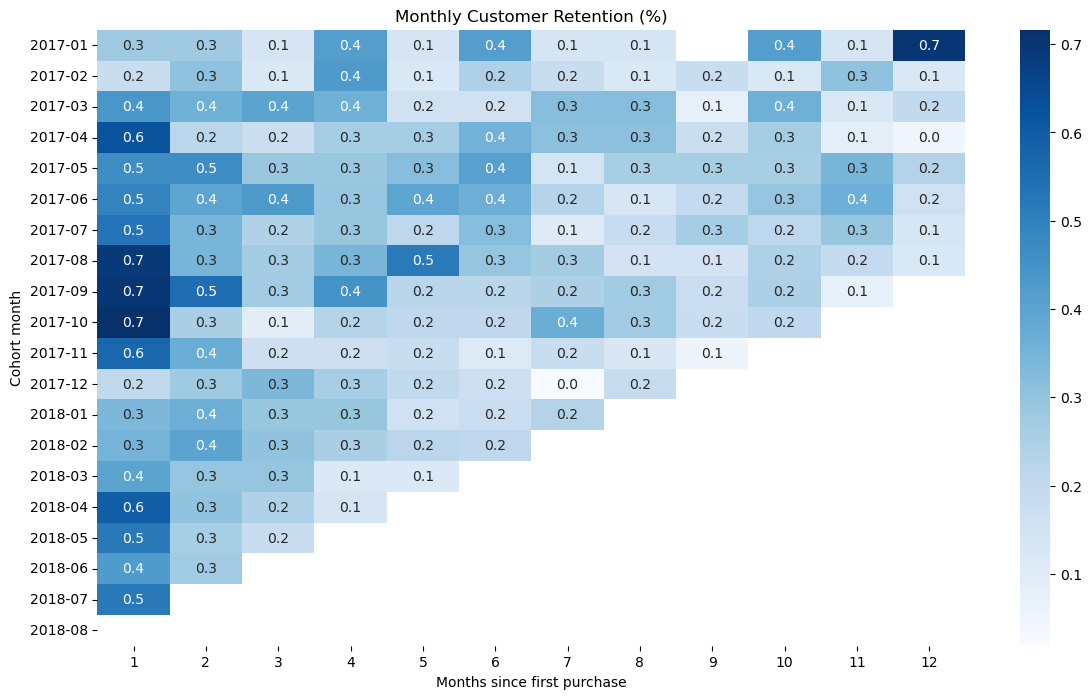

In [23]:
retention_plot = retention.iloc[:, 1:13].copy()
retention_plot.index = retention_plot.index.astype(str)

plt.figure(figsize=(14, 8))
sns.heatmap(retention_plot, annot=True, fmt=".1f", cmap="Blues")
plt.title("Monthly Customer Retention (%)")
plt.xlabel("Months since first purchase")
plt.ylabel("Cohort month")
plt.show()

In [24]:
snapshot_date = df["order_purchase_timestamp"].max() + pd.Timedelta(days=1)
print(snapshot_date)

2018-08-30 15:00:37


In [25]:
rfm = df.groupby("customer_unique_id").agg(
    recency=("order_purchase_timestamp", lambda x: (snapshot_date - x.max()).days),
    frequency=("order_id", "nunique"),
    monetary=("payment_value", "sum")
).reset_index()

print(rfm.head())
print(rfm.describe())

                 customer_unique_id  recency  frequency  monetary
0  0000366f3b9a7992bf8c76cfdf3221e2      112          1    141.90
1  0000b849f77a49e4a4ce2b2a4ca5be3f      115          1     27.19
2  0000f46a3911fa3c0805444483337064      537          1     86.22
3  0000f6ccb0745a6a4b88665a16c9f078      321          1     43.62
4  0004aac84e0df4da2b147fca70cf8255      288          1    196.89
            recency     frequency      monetary
count  93358.000000  93358.000000  93358.000000
mean     237.941773      1.033420    165.197003
std      152.591453      0.209097    226.314012
min        1.000000      1.000000      0.000000
25%      114.000000      1.000000     63.052500
50%      219.000000      1.000000    107.780000
75%      346.000000      1.000000    182.557500
max      714.000000     15.000000  13664.080000


In [26]:
rfm["R"] = pd.qcut(rfm["recency"], 4, labels=[4, 3, 2, 1]).astype(int)
rfm["F"] = np.where(rfm["frequency"] == 1, 1, np.where(rfm["frequency"] == 2, 2, 3))
rfm["M"] = pd.qcut(rfm["monetary"].rank(method="first"), 4, labels=[1, 2, 3, 4]).astype(int)

print(rfm[["R", "F", "M"]].describe())

                  R             F            M
count  93358.000000  93358.000000  93358.00000
mean       2.502710      1.032445      2.50000
std        1.118305      0.190466      1.11805
min        1.000000      1.000000      1.00000
25%        2.000000      1.000000      1.25000
50%        3.000000      1.000000      2.50000
75%        4.000000      1.000000      3.75000
max        4.000000      3.000000      4.00000


In [27]:
def segment(row):
    if row["F"] >= 2 and row["R"] >= 3:
        return "Champions"
    elif row["F"] >= 2:
        return "At Risk Repeat"
    elif row["R"] >= 3:
        return "New Customers"
    elif row["M"] >= 3:
        return "Lost High-Value"
    else:
        return "Lost"

rfm["segment"] = rfm.apply(segment, axis=1)
print(rfm["segment"].value_counts())

segment
New Customers      45298
Lost               23589
Lost High-Value    21670
Champions           1549
At Risk Repeat      1252
Name: count, dtype: int64


In [28]:
summary = rfm.groupby("segment").agg(
    customers=("customer_unique_id", "count"),
    avg_spend=("monetary", "mean"),
    total_revenue=("monetary", "sum")
).round(1)

summary["revenue_share_%"] = (summary["total_revenue"] / summary["total_revenue"].sum() * 100).round(1)
print(summary.sort_values("total_revenue", ascending=False))

                 customers  avg_spend  total_revenue  revenue_share_%
segment                                                              
New Customers        45298      161.7      7322796.7             47.5
Lost High-Value      21670      264.4      5729086.7             37.1
Lost                 23589       63.9      1506221.1              9.8
Champions             1549      314.7       487527.2              3.2
At Risk Repeat        1252      301.0       376830.0              2.4


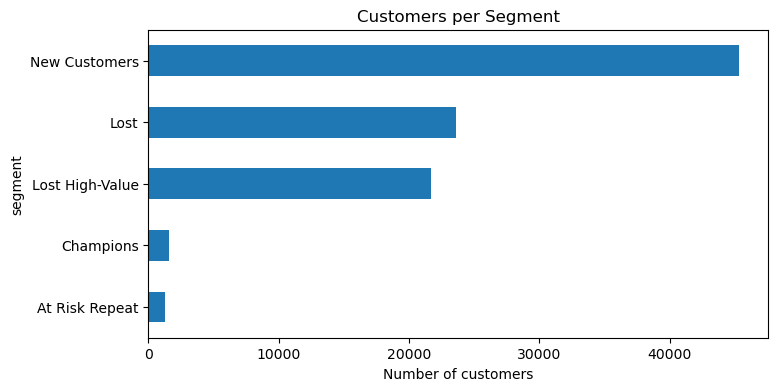

In [29]:
summary["customers"].sort_values().plot(kind="barh", figsize=(8, 4), title="Customers per Segment")
plt.xlabel("Number of customers")
plt.show()

In [30]:
reviews = pd.read_csv(path + "/olist_order_reviews_dataset.csv")
review_score = reviews.groupby("order_id")["review_score"].mean().reset_index()

first_orders = df.sort_values("order_purchase_timestamp").drop_duplicates("customer_unique_id", keep="first")
first_orders = first_orders.merge(review_score, on="order_id", how="left")
first_orders = first_orders.merge(rfm[["customer_unique_id", "frequency"]], on="customer_unique_id")
first_orders["repeat"] = first_orders["frequency"] > 1

print(first_orders.groupby("review_score")["repeat"].mean().mul(100).round(2))

review_score
1.0     2.70
1.5    80.00
2.0     2.69
2.5    50.00
3.0     2.91
3.5    83.33
4.0     2.72
4.5    83.87
5.0     3.08
Name: repeat, dtype: float64


In [31]:
first_orders["late"] = (
    pd.to_datetime(first_orders["order_delivered_customer_date"])
    > pd.to_datetime(first_orders["order_estimated_delivery_date"])
)
print(first_orders.groupby("late")["repeat"].mean().mul(100).round(2))

late
False    3.04
True     2.52
Name: repeat, dtype: float64


In [32]:
# 1. RFM segments
rfm.to_csv("rfm_segments.csv", index=False)

# 2. Segment summary
summary.reset_index().to_csv("segment_summary.csv", index=False)

# 3. Cohort retention (long format, Power BI ki easy)
cohort_long = retention.iloc[:, 1:13].copy()
cohort_long.index = cohort_long.index.astype(str)
cohort_long = cohort_long.reset_index().melt(
    id_vars="cohort_month", var_name="months_since_first", value_name="retention_pct"
)
cohort_long.to_csv("cohort_retention.csv", index=False)

# 4. Monthly trend
monthly = df.groupby("order_month").agg(
    orders=("order_id", "nunique"),
    revenue=("payment_value", "sum")
).reset_index()
monthly["order_month"] = monthly["order_month"].astype(str)
monthly.to_csv("monthly_trend.csv", index=False)